<a href="https://colab.research.google.com/github/daniivelascoo/ifp-programacion-ia/blob/main/Teoria_2_2_B_Clasificacion_Logistica_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Teoría Bloque B: Clasificación (La Frontera de Decisión)
**Sprint 2.2 - Algoritmos de Machine Learning**

Cuando la respuesta a tu pregunta es una **Etiqueta** o Categoría (¿Enfermo/Sano? ¿Spam/No Spam? ¿Gato/Perro?), estamos ante un problema de **CLASIFICACIÓN**.

Hoy veremos el algoritmo rey de la clasificación binaria: la **Regresión Logística**.
*(Nota: Aunque se llame "Regresión", ¡se usa para Clasificar!)*

### 🎯 Objetivos:
1.  **Clases:** Predecir etiquetas discretas (0 o 1).
2.  **Probabilidad:** Entender que la IA trabaja con porcentajes de confianza (`predict_proba`).
3.  **Frontera de Decisión:** La línea invisible que separa los grupos.

## 1. El Problema: Glucosa vs Diabetes

Tenemos datos médicos de pacientes. Queremos saber si un nivel alto de glucosa implica diabetes.
*   **0:** Sano.
*   **1:** Diabético.

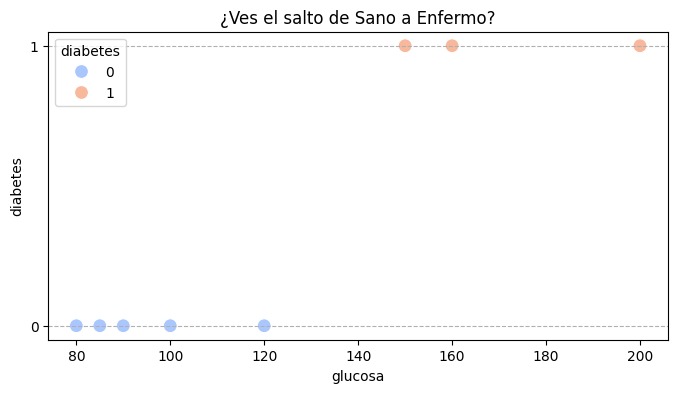

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Datos simples
df = pd.DataFrame({
    'glucosa': [80, 90, 100, 120, 150, 200, 85, 160], # Feature
    'diabetes': [0,  0,   0,   0,   1,   1,   0,   1] # Target (Clases)
})

# Visualizamos
plt.figure(figsize=(8, 4))

# Usamos 'hue' para pintar de color distinto a los enfermos
sns.scatterplot(data=df, x='glucosa', y='diabetes', hue='diabetes', s=100, palette='coolwarm')

plt.title("¿Ves el salto de Sano a Enfermo?")
plt.yticks([0, 1]) # Solo mostramos 0 y 1 en el eje Y
plt.grid(True, axis='y', linestyle='--')
plt.show()

## 2. Entrenando la Regresión Logística

Este algoritmo no dibuja una línea recta infinita (como la Regresión Lineal).
Dibuja una curva en forma de "S" (Sigmoide) que va del 0 al 1.

In [2]:
from sklearn.linear_model import LogisticRegression

# 1. PREPARAR DATOS
X = df[['glucosa']]
y = df['diabetes']

# 2. INSTANCIAR
clf = LogisticRegression()

# 3. ENTRENAR
print("🧠 Aprendiendo a diagnosticar...")
clf.fit(X, y) # TODO: Usa .fit()

print("¡Modelo entrenado!")

🧠 Aprendiendo a diagnosticar...
¡Modelo entrenado!


## 3. Predicción vs Probabilidad

Aquí está la magia. Podemos pedirle al modelo dos cosas:
1.  **La Decisión (`predict`):** ¿Es 0 o 1? (El modelo corta por el 50%).
2.  **La Confianza (`predict_proba`):** ¿Qué tan seguro estás?

In [4]:
# Llega un paciente con 135 de glucosa. Está en el límite.
paciente = pd.DataFrame({'glucosa': [135]})

# 1. PREDICCIÓN DURA (Clase)
prediccion = clf.predict(paciente) # TODO: Usa .predict()

# 2. PROBABILIDAD (Confianza)
# Esto devuelve dos números: [Probabilidad de 0, Probabilidad de 1]
probs = clf.predict_proba(paciente) # TODO: Usa .predict_proba()

print(f"Glucosa 135 -> Clase Predicha: {prediccion[0]}")
print(f"Probabilidad de estar Sano (0):    {probs[0][0]:.2%}")
print(f"Probabilidad de ser Diabético (1): {probs[0][1]:.2%}")

# Reflexión:
# Si sale 51% de probabilidad, dirá que es Diabético.
# Pero un médico querría ver ese porcentaje para decidir.

Glucosa 135 -> Clase Predicha: 1
Probabilidad de estar Sano (0):    49.45%
Probabilidad de ser Diabético (1): 50.55%


## 4. Visualizando la "S" (La Curva Sigmoide)

Vamos a ver cómo piensa la máquina. Pintaremos la probabilidad para todos los niveles de glucosa.

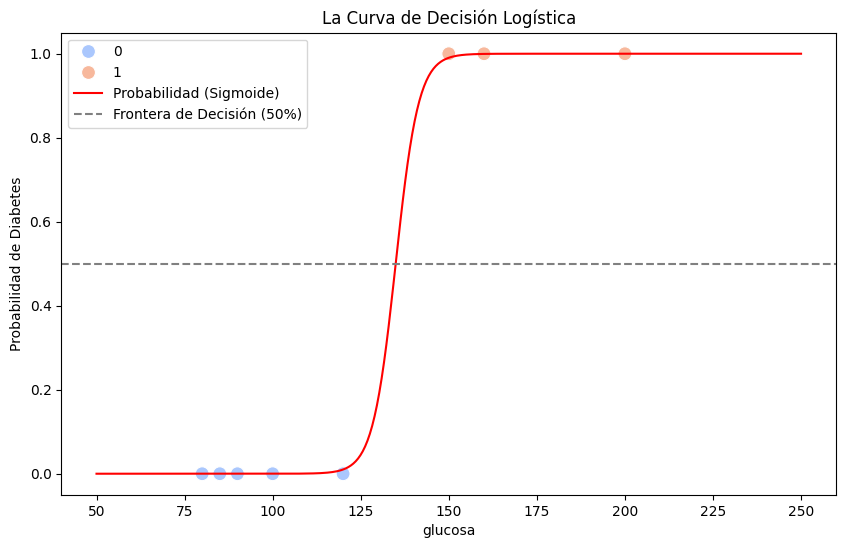

In [5]:
# 1. Generamos glucosa desde 50 hasta 250 para pintar la curva suave (NumPy)
rango_glucosa = np.linspace(50, 250, 300).reshape(-1, 1)

# 2. CORRECCIÓN: Lo convertimos a DataFrame con el nombre correcto
# Así el modelo no se queja de que faltan nombres
X_test_visual = pd.DataFrame(rango_glucosa, columns=['glucosa'])

# 3. Predecimos la probabilidad
# Nos quedamos con la columna 1 (Probabilidad de Diabetes)
y_prob_visual = clf.predict_proba(X_test_visual)[:, 1]

plt.figure(figsize=(10, 6))

# Pintamos los datos reales (Puntos)
sns.scatterplot(data=df, x='glucosa', y='diabetes', hue='diabetes', s=100, palette='coolwarm')

# Pintamos la curva de la IA (Línea roja)
# Nota: Para el plot usamos rango_glucosa (el numérico) en el eje X
plt.plot(rango_glucosa, y_prob_visual, color='red', label='Probabilidad (Sigmoide)')

# Pintamos la frontera del 50%
plt.axhline(0.5, color='gray', linestyle='--', label='Frontera de Decisión (50%)')

plt.legend()
plt.title("La Curva de Decisión Logística")
plt.ylabel("Probabilidad de Diabetes")
plt.show()